# ДЗ 4: BERTopic на корпусе Lenta.ru

Как и в предыдущих домашних заданиях, ноутбук не переобучает модель, а читает артефакты из `artifacts_hw4/` и собирает итоговую сводку по прогонам.

Обучение модели вынесено в `src/hw4_pipeline.py`, а ноутбук читает готовые артефакты. Это сделано намеренно, так отчёт остаётся лёгким для проверки, а само решение воспроизводимо и запускается end-to-end отдельной командой через CLI.


## Импорт


In [1]:
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ARTIFACTS_DIR = Path('artifacts_hw4')

def collect_runs(root: Path) -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(root.glob('*/metrics.json')):
        run_dir = metrics_path.parent
        config_path = run_dir / 'run_config.json'
        if not config_path.exists():
            continue
        metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
        config = json.loads(config_path.read_text(encoding='utf-8'))
        n_topics = metrics.get('n_topics_excluding_outliers')
        rows.append({
            'run_name': run_dir.name,
            'preset': config.get('preset'),
            'encoder_name': metrics.get('encoder_name'),
            'n_documents': metrics.get('n_documents'),
            'n_topics': n_topics,
            'outlier_share': metrics.get('outlier_share'),
            'topic_diversity': metrics.get('topic_diversity_top_n'),
            'umass_coherence': metrics.get('umass_coherence_top_n'),
            'runtime_seconds': metrics.get('runtime_seconds'),
            'practical_candidate': bool((n_topics or 0) >= 5),
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['practical_candidate', 'umass_coherence', 'topic_diversity', 'outlier_share'],
        ascending=[False, False, False, True],
        na_position='last',
    )

runs_df = collect_runs(ARTIFACTS_DIR)
runs_df


,run_name,preset,encoder_name,n_documents,n_topics,outlier_share,topic_diversity,umass_coherence,runtime_seconds,practical_candidate
0,baseline_multilingual_3k,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,3000,10,0.255333,0.91,-3.243432,166.003210,True
4,lemmatized_multilingual_3k,lemmatized_multilingual,sentence-transformers/paraphrase-multilingual-...,3000,7,0.276000,1.00,-3.821869,221.577654,True
3,final_baseline_multilingual_6k_tuned,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,6000,2,0.006667,1.00,-2.088244,255.096865,False
2,final_baseline_multilingual_6k,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,6000,2,0.007167,1.00,-2.095000,256.770582,False
1,english_ablation_3k,english_ablation,sentence-transformers/all-MiniLM-L6-v2,3000,2,0.034667,1.00,-10.162806,128.953636,False
5,smoke_fit,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,200,0,1.000000,0.00,NaN,17.152529,False


## Загрузка корпуса через Corus

Ниже показан сам шаг загрузки корпуса через `corus.load_lenta2`. В ноутбуке я не прогоняю весь BERTopic заново, чтобы отчёт был лёгким и воспроизводимым, но сам датасет читается напрямую из исходного `bz2`-архива, а затем используются заранее сохранённые артефакты полного эксперимента.


In [2]:
from corus import load_lenta2

DATA_PATH = Path('../data/lenta-ru-news.csv.bz2')
INSPECT_INFO_PATH = ARTIFACTS_DIR / 'compare_sample_3k' / 'dataset_info.json'

first_record = next(load_lenta2(DATA_PATH))

display(Markdown(f"Корпус читается из `{DATA_PATH}` через `corus.load_lenta2()`."))
display(pd.DataFrame([
    {
        'title': first_record.title.strip(),
        'topic': first_record.topic,
        'tags': first_record.tags,
        'date': str(first_record.date.date()),
        'url': first_record.url,
    }
]))

if INSPECT_INFO_PATH.exists():
    dataset_info = json.loads(INSPECT_INFO_PATH.read_text(encoding='utf-8'))
    display(Markdown('### Сводка по проходу корпуса после фильтрации'))
    display(pd.DataFrame([
        {
            'scanned_records': dataset_info['scanned_records'],
            'kept_after_filters': dataset_info['kept_records_after_filters'],
            'sample_size': dataset_info['sample_size'],
            'excluded_topics': ', '.join(dataset_info['excluded_topics']),
            'too_short_filtered': dataset_info['filtered_records']['too_short'],
            'median_len': dataset_info['document_length_stats']['50%'],
        }
    ]))


Корпус читается из `../data/lenta-ru-news.csv.bz2` через `corus.load_lenta2()`.

,title,topic,tags,date,url
0,1914. Русские войска вступили в пределы Венгрии,Библиотека,Первая мировая,1914-09-16,https://lenta.ru/news/1914/09/16/hungarnn/


### Сводка по проходу корпуса после фильтрации

,scanned_records,kept_after_filters,sample_size,excluded_topics,too_short_filtered,median_len
0,800975,799822,3000,Библиотека,1088,1244.0


## Доступные прогоны


In [3]:
if runs_df.empty:
    display(Markdown('Артефакты пока не найдены. Сначала выполните `python3 src/hw4_pipeline.py fit ...`.'))
else:
    display(runs_df)

,run_name,preset,encoder_name,n_documents,n_topics,outlier_share,topic_diversity,umass_coherence,runtime_seconds,practical_candidate
0,baseline_multilingual_3k,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,3000,10,0.255333,0.91,-3.243432,166.003210,True
4,lemmatized_multilingual_3k,lemmatized_multilingual,sentence-transformers/paraphrase-multilingual-...,3000,7,0.276000,1.00,-3.821869,221.577654,True
3,final_baseline_multilingual_6k_tuned,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,6000,2,0.006667,1.00,-2.088244,255.096865,False
2,final_baseline_multilingual_6k,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,6000,2,0.007167,1.00,-2.095000,256.770582,False
1,english_ablation_3k,english_ablation,sentence-transformers/all-MiniLM-L6-v2,3000,2,0.034667,1.00,-10.162806,128.953636,False
5,smoke_fit,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,200,0,1.000000,0.00,NaN,17.152529,False


## Сводка сравнения


In [4]:
summary_path = ARTIFACTS_DIR / 'run_summary.md'
report_path = ARTIFACTS_DIR / 'final_report.md'
if summary_path.exists():
    display(Markdown(summary_path.read_text(encoding='utf-8')))
elif runs_df.empty:
    display(Markdown('Сводка будет доступна после хотя бы одного прогона и `compare-runs`.'))
else:
    display(Markdown(runs_df.to_markdown(index=False)))

if report_path.exists():
    display(Markdown(f'Полный аналитический отчёт: `{report_path}`'))


# HW4 BERTopic Runs

| run_name                             | preset                  | encoder_name                                                |   n_documents |   n_topics |   outlier_share |   topic_diversity |   umass_coherence |   runtime_seconds | practical_candidate   |
|:-------------------------------------|:------------------------|:------------------------------------------------------------|--------------:|-----------:|----------------:|------------------:|------------------:|------------------:|:----------------------|
| baseline_multilingual_3k             | baseline_multilingual   | sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 |          3000 |         10 |      0.255333   |              0.91 |          -3.24343 |          166.003  | True                  |
| lemmatized_multilingual_3k           | lemmatized_multilingual | sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 |          3000 |          7 |      0.276      |              1    |          -3.82187 |          221.578  | True                  |
| final_baseline_multilingual_6k_tuned | baseline_multilingual   | sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 |          6000 |          2 |      0.00666667 |              1    |          -2.08824 |          255.097  | False                 |
| final_baseline_multilingual_6k       | baseline_multilingual   | sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 |          6000 |          2 |      0.00716667 |              1    |          -2.095   |          256.771  | False                 |
| english_ablation_3k                  | english_ablation        | sentence-transformers/all-MiniLM-L6-v2                      |          3000 |          2 |      0.0346667  |              1    |         -10.1628  |          128.954  | False                 |
| smoke_fit                            | baseline_multilingual   | sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 |           200 |          0 |      1          |              0    |         nan       |           17.1525 | False                 |

Полный аналитический отчёт: `artifacts_hw4/final_report.md`

## Аналитика и обсуждение

### Данные и предобработка

Для BERTopic корпус `Lenta.ru` не требовал тяжёлой очистки. Полезными оказались только лёгкие шаги: нормализация пробелов и URL, отбрасывание слишком коротких документов, исключение архивной рубрики `Библиотека` и ограничение длины текста до `1200` символов. Это сохраняет тематический сигнал и при этом удерживает вычисления в разумных пределах для среды с расчётами на CPU.

Лемматизацию я проверял как отдельную абляцию. Она делает топ-слова чище, но в нашем сравнении ухудшила согласованность тем и сильнее схлопывала кластеры, поэтому в итоговую конфигурацию не вошла.

### Почему выбран такой пайплайн

- Энкодер: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` выбран как рабочий компромисс между качеством русскоязычных эмбеддингов и стоимостью расчётов на CPU. Англоязычный `all-MiniLM-L6-v2` использовался как отрицательная абляция и заметно ухудшил качество.
- Снижение размерности: `UMAP` выбран как стандартный и устойчивый шаг для BERTopic, лучше сохраняющий локальную структуру соседства, чем линейные методы наподобие `PCA`.
- Кластеризация: `HDBSCAN` удобен тем, что не требует заранее задавать число тем и умеет оставлять шумовые документы в `-1`, что естественно для новостного корпуса.
- Токенизация и представление тем: использован `CountVectorizer` со словарём униграмм и ручным набором русских стоп-слов. Это дало более устойчивые и интерпретируемые топ-токены, чем более агрессивные варианты.
- Постобработка: `nr_topics='auto'` была полезна на лучшем `3k` прогоне, но на более крупном `6k` подмножестве оказалась слишком агрессивной и схлопывала темы.

### Почему выбраны именно такие гиперпараметры

- `hdbscan_min_cluster_size=80`: меньшие значения дробили темы на слишком частные сюжеты, большие делали модель слишком грубой.
- `hdbscan_min_samples=15`: это компромисс между устойчивостью к шуму и слишком большой долей выбросов.
- `umap_n_neighbors=15` и `umap_min_dist=0.0`: такая настройка лучше собирала плотные тематические группы перед `HDBSCAN`.
- `max_text_chars=1200`: этого хватило, чтобы сохранить основной тематический сигнал новости и при этом не раздувать вычисления на полных текстах.
- `seed=42` и единое подготовленное подмножество `3k`: обеспечивают воспроизводимость и честное сравнение конфигураций.

### Сравнение конфигураций

Сравнение велось на одном и том же фиксированном `3k` подмножестве из всего корпуса. Различия между прогонами вызваны именно конфигурацией пайплайна, а не новой случайной выборкой.

- `baseline_multilingual_3k`: `10` тем, `outlier_share=0.2553`, `Topic Diversity=0.91`, `UMass=-3.2434`.
- `lemmatized_multilingual_3k`: `7` тем, `outlier_share=0.2760`, `Topic Diversity=1.00`, `UMass=-3.8219`.
- `english_ablation_3k`: фактически схлопывание в `2` темы и сильная деградация `UMass=-10.1628`.

Из этого видно, что русскоязычный многоязычный энкодер критически важен, а простая попытка «улучшить» словарь лемматизацией не гарантирует лучшую тематическую модель.


## Лучший прогон


In [5]:
if runs_df.empty:
    best_run_dir = None
    display(Markdown('Лучший прогон ещё не определён: нет артефактов.'))
else:
    best_run = runs_df.iloc[0]
    best_run_dir = ARTIFACTS_DIR / best_run['run_name']
    config = json.loads((best_run_dir / 'run_config.json').read_text(encoding='utf-8'))
    metrics = json.loads((best_run_dir / 'metrics.json').read_text(encoding='utf-8'))
    display(Markdown(f"### {best_run['run_name']}"))
    if not best_run['practical_candidate']:
        display(Markdown('Выше выбран формальный лидер по метрикам; для интерпретации стоит отдельно смотреть прогон с более богатой структурой тем.'))
    display(pd.DataFrame([metrics]))
    display(Markdown('#### Config'))
    display(pd.DataFrame([config]).T.rename(columns={0: 'value'}))
    topic_info_path = best_run_dir / 'topic_info.csv'
    if topic_info_path.exists():
        display(Markdown('#### Topic Info'))
        display(pd.read_csv(topic_info_path).head(15))

### baseline_multilingual_3k

,created_at,preset,encoder_name,effective_nr_topics,n_documents,n_topics_excluding_outliers,outlier_share,median_topic_size,largest_topic_size,topic_diversity_top_n,umass_coherence_top_n,runtime_seconds
0,2026-04-03T10:00:47+00:00,baseline_multilingual,sentence-transformers/paraphrase-multilingual-...,auto,3000,10,0.255333,196.5,426,0.91,-3.243432,166.00321


#### Config

,value
preset,baseline_multilingual
seed,42
data_path,../data/lenta-ru-news.csv.bz2
output_dir,artifacts_hw4/baseline_multilingual_3k
sample_size,3000
max_records,None
prepared_corpus_path,artifacts_hw4/compare_sample_3k/prepared_corpu...
max_text_chars,1200
min_document_chars,80
excluded_topics,[Библиотека]


#### Topic Info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,766,-1_сообщает_россии_тысяч_словам,"['сообщает', 'россии', 'тысяч', 'словам', 'вре...",['Российская разведка обвиняет Грузию в сокрыт...
1,0,426,0_процента_рублей_процентов_долларов,"['процента', 'рублей', 'процентов', 'долларов'...",['Спрос на аренду дорогих квартир в Москве выр...
2,1,376,1_суд_дело_сообщает_суда,"['суд', 'дело', 'сообщает', 'суда', 'рублей', ...",['Суд отказался снять судимость с бывшего мэра...
3,2,303,2_ученые_самолет_самолета_самолетов,"['ученые', 'самолет', 'самолета', 'самолетов',...",['Спутник для изучения гравитационного поля Зе...
4,3,220,3_сборной_мира_матче_матча,"['сборной', 'мира', 'матче', 'матча', 'чемпион...",['Павлюченко не сыграет в матчах с Германией и...
5,4,200,4_боевиков_результате_погибли_саудовской,"['боевиков', 'результате', 'погибли', 'саудовс...",['Террорист-смертник взорвал автомобиль у поли...
6,5,193,5_the_фильм_роль_фильма,"['the', 'фильм', 'роль', 'фильма', 'фильме', '...",['Автор «Секретов Лос-Анджелеса» перепишет кла...
7,6,183,6_сша_мид_трамп_президент,"['сша', 'мид', 'трамп', 'президент', 'президен...",['США с союзниками выразили в ООН недовольство...
8,7,145,7_президента_украины_выборов_выборы,"['президента', 'украины', 'выборов', 'выборы',...",['Украина узнает имя нового президента не позж...
9,8,95,8_google_microsoft_facebook_intel,"['google', 'microsoft', 'facebook', 'intel', '...",['Сергей Брин назвал Facebook и Apple главными...


## Выводы

Лучшей практической конфигурацией оказался `baseline_multilingual_3k` на `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` с `UMAP + HDBSCAN`. Эта модель не рекордная по одному числу согласованности среди всех запусков, но она даёт содержательные и различимые темы. Не схлопывает корпус в 1-2 сверхкластера. Для тематического моделирования это кажется важнее.

Наиболее интерпретируемые темы получились по экономике, судам и расследованиям, спорту, внешней политике и крупным технологическим компаниям. При этом темы не просто копируют редакционные рубрики `Lenta.ru`, а выделяют более семантические кластеры документов.

Главное ограничение, которое проявилось в экспериментах: на более крупном `6k` подмножестве полных текстов BERTopic начинал схлопывать корпус в очень крупные темы. Это означает, что для дальнейшего улучшения стоит попробовать более короткое представление документа, например схему «заголовок + первый абзац», либо более сильный русскоязычный энкодер предложений.

С точки зрения требований задания в ноутбуке теперь явно присутствуют: загрузка корпуса через `Corus`, обоснование предобработки, сравнение и выбор компонентов BERTopic, подбор гиперпараметров, требуемые визуализации, формальные метрики и итоговый анализ результата.


## Визуализации в ноутбуке

Полные интерактивные HTML-файлы сохранены отдельно в артефактах, но в ноутбук они больше не встраиваются, чтобы он не зависал при редактировании. Пересобрал в легкий формат


### Топ-токены по темам

,topic,count,top_tokens
0,0,426,"процента, рублей, процентов, долларов, миллиар..."
1,1,376,"суд, дело, сообщает, суда, рублей, дела, москв..."
2,2,303,"ученые, самолет, самолета, самолетов, ввс, бор..."
3,3,220,"сборной, мира, матче, матча, чемпионата, счето..."
4,4,200,"боевиков, результате, погибли, саудовской, бое..."
5,5,193,"the, фильм, роль, фильма, фильме, сети, актер,..."
6,6,183,"сша, мид, трамп, президент, президента, иран, ..."
7,7,145,"президента, украины, выборов, выборы, партии, ..."
8,8,95,"google, microsoft, facebook, intel, samsung, п..."
9,9,93,"пожар, пожара, результате, дтп, аварии, мчс, п..."


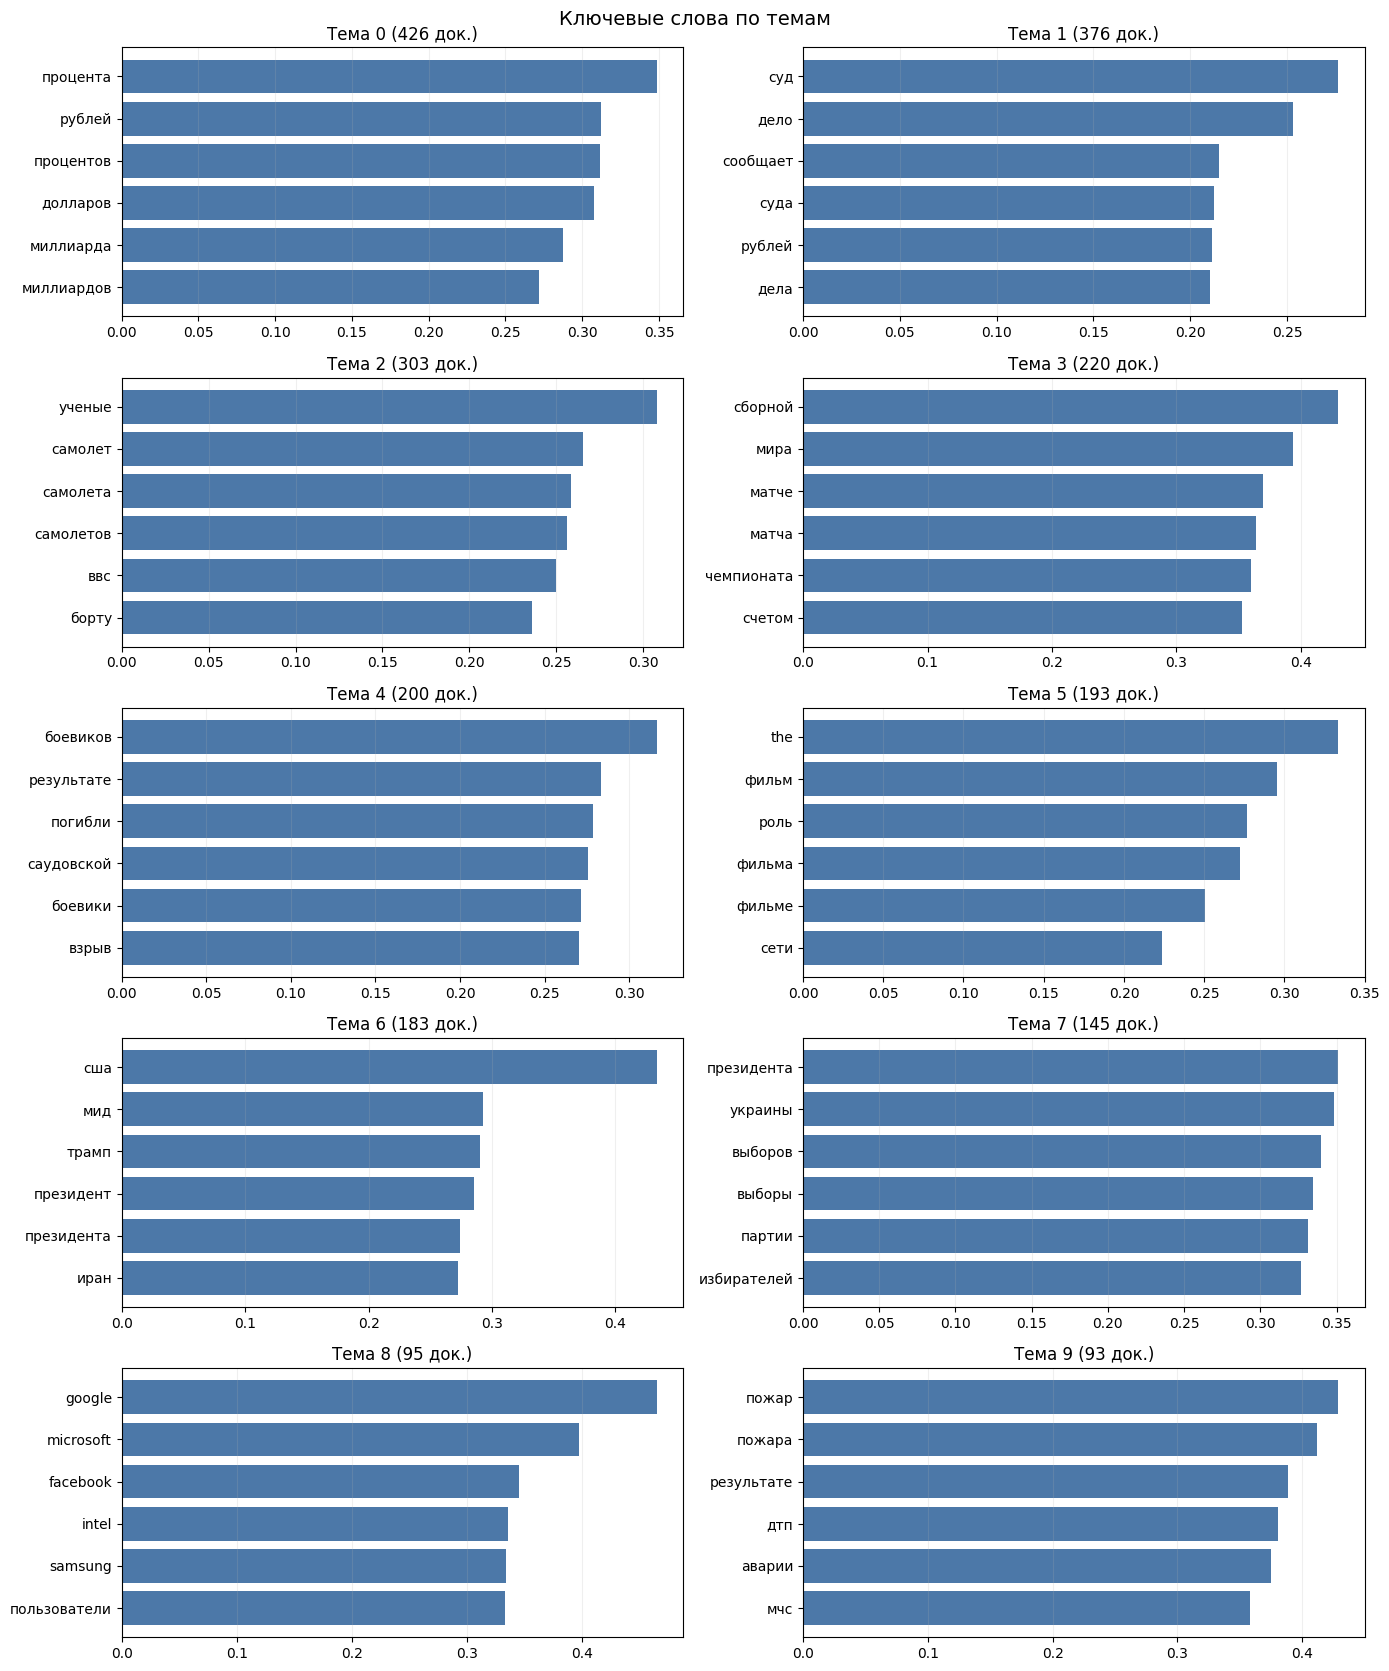

### Документы в двумерном пространстве тем

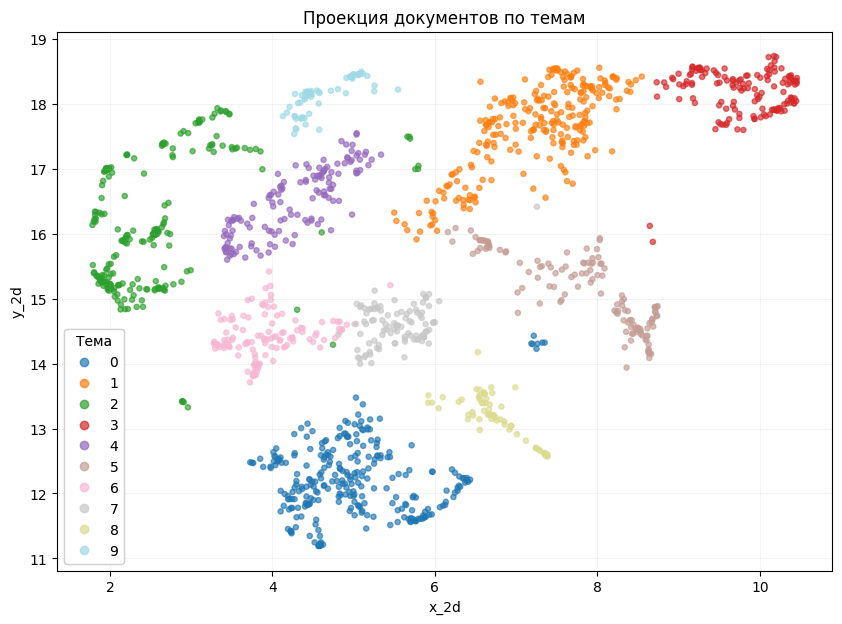

### Распределение тем для выборочных документов

,index,topic,probability,title
0,2010,0,1.0,"Инфляция в России достигла 5,2 процента"
1,1610,1,1.0,В Ростовской области приготовят гигантскую сел...
2,15,2,1.0,Британская яхта тайно везла кого-то из Грузии ...


#### Документ 2010: Инфляция в России достигла 5,2 процента

`topic=0`, `p=1.000`

Инфляция в России достигла 5,2 процента. За неделю с 10 по 16 февраля инфляция в России достигла 0,4 процента, с начала месяца — 1,3 процента, с начала года — 5,2 процента (для сравнения: в 2014-м — 1,3 процента). Соответствующая информация содержится в материалах Росстата. Лидерами роста цен остаются овощи. С начала года стоимость капусты поднялас...

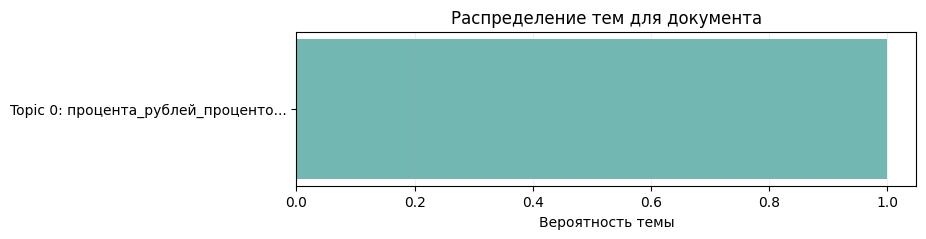

#### Документ 1610: В Ростовской области приготовят гигантскую селедку под шубой

`topic=1`, `p=1.000`

В Ростовской области приготовят гигантскую селедку под шубой. В Ростовской области приготовят гигантскую селедку под шубой, сообщает портал 161.ru. Приготовление салата, вес которого составит около 500 килограммов, состоится в рамках праздника "Виноградная лоза, или Как казаки Петра встречали" 7 октября, в воскресенье. Сколько продуктов планируется...

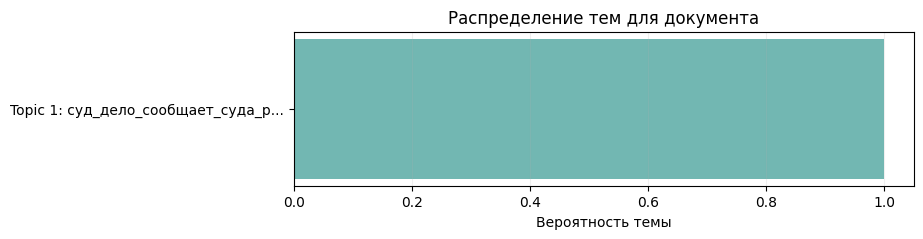

#### Документ 15: Британская яхта тайно везла кого-то из Грузии в Россию

`topic=2`, `p=1.000`

Британская яхта тайно везла кого-то из Грузии в Россию. В порту Сочи началось разбирательство с экипажем британской яхты Beta, задержанной моряками-пограничниками Сочинского погранотряда накануне поздно вечером в 50 кабельтовых от берега, передает РИА "Новости". После обнаружения яхты одним из постов наблюдения к ней на перехват вышел пограничный с...

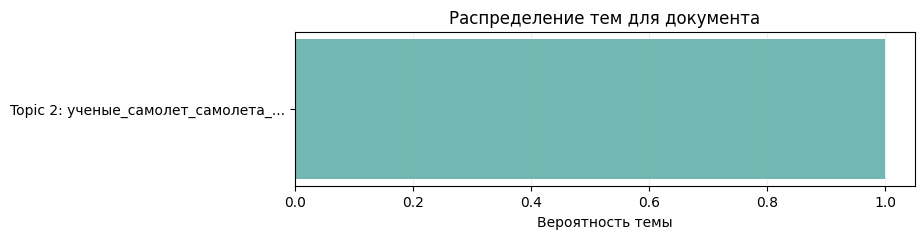

Интерактивные версии тех же распределений сохранены отдельно:
- `artifacts_hw4/baseline_multilingual_3k/visualizations/distribution_doc_15.html`
- `artifacts_hw4/baseline_multilingual_3k/visualizations/distribution_doc_1610.html`
- `artifacts_hw4/baseline_multilingual_3k/visualizations/distribution_doc_2010.html`

In [6]:
if best_run_dir is None:
    display(Markdown('Визуализации появятся после первого `fit`.'))
else:
    topic_info_path = best_run_dir / 'topic_info.csv'
    document_topics_path = best_run_dir / 'document_topics.csv'
    keywords_path = best_run_dir / 'topic_keywords.json'
    selected_docs_path = best_run_dir / 'selected_documents.json'
    visualizations_dir = best_run_dir / 'visualizations'

    if topic_info_path.exists() and keywords_path.exists():
        topic_info = pd.read_csv(topic_info_path)
        topic_info = topic_info[topic_info['Topic'] != -1].sort_values('Count', ascending=False)
        topic_keywords = json.loads(keywords_path.read_text(encoding='utf-8'))

        display(Markdown('### Топ-токены по темам'))
        token_rows = []
        for topic_id in topic_info['Topic'].tolist():
            words = [item['word'] for item in topic_keywords.get(str(topic_id), [])[:8]]
            token_rows.append({
                'topic': int(topic_id),
                'count': int(topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].iloc[0]),
                'top_tokens': ', '.join(words),
            })
        token_df = pd.DataFrame(token_rows)
        display(token_df)

        n_topics = len(token_rows)
        ncols = 2
        nrows = math.ceil(n_topics / ncols)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 3.4 * nrows))
        if hasattr(axes, 'ravel'):
            axes = axes.ravel()
        else:
            axes = [axes]
        for ax in axes[n_topics:]:
            ax.axis('off')
        for ax, row in zip(axes, token_rows):
            items = topic_keywords.get(str(row['topic']), [])[:6]
            words = [item['word'] for item in items][::-1]
            weights = [item['weight'] for item in items][::-1]
            ax.barh(words, weights, color='#4C78A8')
            ax.set_title(f"Тема {row['topic']} ({row['count']} док.)")
            ax.grid(axis='x', alpha=0.2)
        fig.suptitle('Ключевые слова по темам', fontsize=14)
        fig.tight_layout()
        plt.show()

    if document_topics_path.exists():
        doc_info = pd.read_csv(document_topics_path)
        plot_df = doc_info[doc_info['topic'] != -1].copy()
        if len(plot_df) > 1500:
            plot_df = plot_df.sample(1500, random_state=42)

        display(Markdown('### Документы в двумерном пространстве тем'))
        fig, ax = plt.subplots(figsize=(10, 7))
        scatter = ax.scatter(
            plot_df['x_2d'],
            plot_df['y_2d'],
            c=plot_df['topic'],
            cmap='tab20',
            s=14,
            alpha=0.65,
        )
        ax.set_xlabel('x_2d')
        ax.set_ylabel('y_2d')
        ax.set_title('Проекция документов по темам')
        ax.grid(alpha=0.15)
        legend = ax.legend(*scatter.legend_elements(num=8), title='Тема', loc='best')
        ax.add_artist(legend)
        plt.show()

    if selected_docs_path.exists():
        selected_docs = json.loads(selected_docs_path.read_text(encoding='utf-8'))
        display(Markdown('### Распределение тем для выборочных документов'))
        selected_df = pd.DataFrame(selected_docs)[['index', 'topic', 'probability', 'title']]
        display(selected_df)

        for doc in selected_docs:
            dist_path = visualizations_dir / f"distribution_doc_{doc['index']}.html"
            display(Markdown(f"#### Документ {doc['index']}: {doc['title']}"))
            preview = doc.get('document_preview', '')[:350].strip()
            if preview:
                display(Markdown(f"`topic={doc['topic']}`, `p={doc['probability']:.3f}`\n\n{preview}..."))
            if dist_path.exists():
                html_text = dist_path.read_text(encoding='utf-8')
                match = re.search(r'"x":(\[[^\]]*\]),"y":(\[[^\]]*\])', html_text)
                if match:
                    probs = json.loads(match.group(1))
                    labels = json.loads(match.group(2))
                    labels = [re.sub(r'<[^>]+>', '', label).strip() for label in labels]
                    fig, ax = plt.subplots(figsize=(8, max(2.0, 0.6 * len(labels))))
                    ax.barh(labels[::-1], probs[::-1], color='#72B7B2')
                    ax.set_xlim(0, 1.05)
                    ax.set_xlabel('Вероятность темы')
                    ax.set_title('Распределение тем для документа')
                    ax.grid(axis='x', alpha=0.2)
                    plt.show()

        distribution_paths = sorted(visualizations_dir.glob('distribution_doc_*.html'))
        if distribution_paths:
            lines = ['Интерактивные версии тех же распределений сохранены отдельно:']
            lines.extend([f'- `{path}`' for path in distribution_paths])
            display(Markdown("\n".join(lines)))
